In [52]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sympy as smp
from scipy.stats import bernoulli
import pandas as pd
import math
import pylatexenc
from IPython.display import display, Math
from qc_module import steady_state_linear_oqw, erf_approximation, S_G, S_corrected, Prob, S_entropy, t_start, t_end, mean_energy, standart_deviation_energy, S_a_2, S_a_3, Prob_approximation, mean_energy_evolution
from scipy.special import erf
import matplotlib.font_manager as fm

font_path = 'C:\\Users\\pedro\\Downloads\\times.ttf'  # Update this path if necessary
font_prop = fm.FontProperties(fname=font_path)

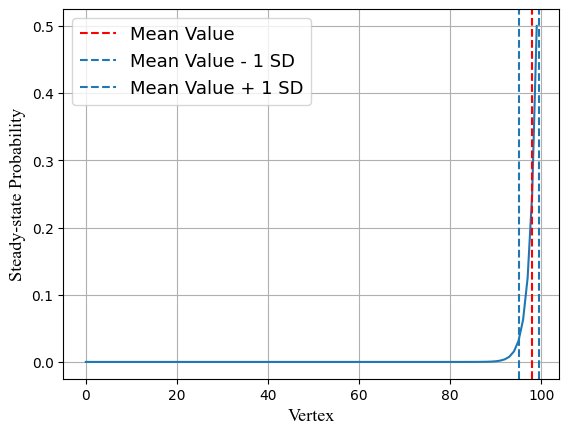

In [53]:
omega = 2/3
N = 100

list = range(N)

plt.plot(list,steady_state_linear_oqw(omega,N)   )
plt.xlabel('Vertex', fontsize=13, fontproperties=font_prop)
plt.ylabel('Steady-state Probability', fontsize=13, fontproperties=font_prop)

plt.axvline(x=mean_energy(N,omega,1), color='red', linestyle='--', label='Mean Value')
plt.axvline(x=mean_energy(N,omega,1)-standart_deviation_energy(N,omega,2), linestyle='--', label='Mean Value - 1 SD')
plt.axvline(x=mean_energy(N,omega,1)+standart_deviation_energy(N,omega,1), linestyle='--', label='Mean Value + 1 SD')

plt.legend(fontsize=13)
plt.grid(True)
plt.show()

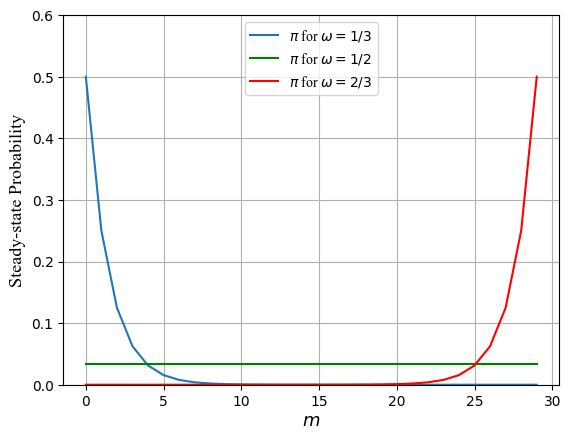

In [54]:
omega1 = 1/3
omega2 = 1/2
omega3 = 2/3
N = 30

list = range(N)

plt.plot(list,steady_state_linear_oqw(omega1,N), label=r"$\pi$ for $\omega = 1/3$"   )
plt.plot(list,steady_state_linear_oqw(omega2,N), color = 'green', label=r"$\pi$ for $\omega = 1/2$"   )
plt.plot(list,steady_state_linear_oqw(omega3,N), color = 'red', label=r"$\pi$ for $\omega = 2/3$"   )

plt.xlabel('$m$', fontsize = 13, fontproperties=font_prop)
plt.ylabel('Steady-state Probability', fontsize=13, fontproperties=font_prop)
plt.legend(prop=font_prop, fontsize = 13)
plt.grid(True)
plt.ylim(0, 0.6)

plt.savefig("steady_state_omega.pgf")


plt.show()

In [55]:
# Define omega avoiding 0 and 1 to prevent division by zero
omega = np.linspace(0.01, 0.99, 1000)

# Define lambda = 1 - omega
lmbd = 1 - omega

# Compute T
T = -1 / (np.log(omega / lmbd))

<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
C:\Users\pedro\AppData\Local\Temp\ipykernel_7704\61364070.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$T(\omega)$', fontsize=13, fontproperties=font_prop)


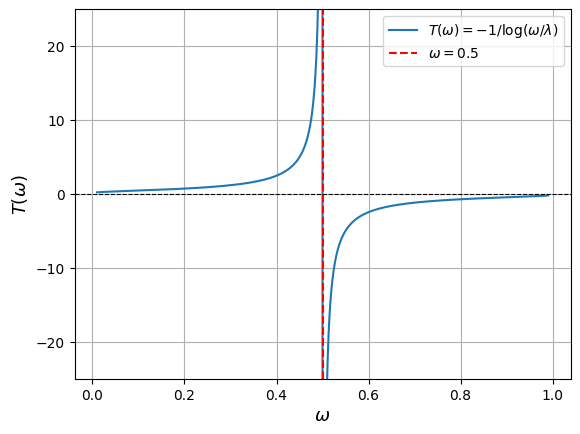

In [56]:
# Plot
plt.plot(omega, T, label=r"$T(\omega) = -1/\log(\omega/\lambda)$")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0.5, color='red', linestyle='--', label=r'$\omega = 0.5$')
plt.xlabel(r'$\omega$', fontsize=13, fontproperties=font_prop)
plt.ylabel('$T(\omega)$', fontsize=13, fontproperties=font_prop)
plt.legend(prop=font_prop, fontsize = 13)
plt.grid(True)
plt.ylim(-25, 25)
plt.savefig("temperature_vs_omega.pgf")

plt.show()


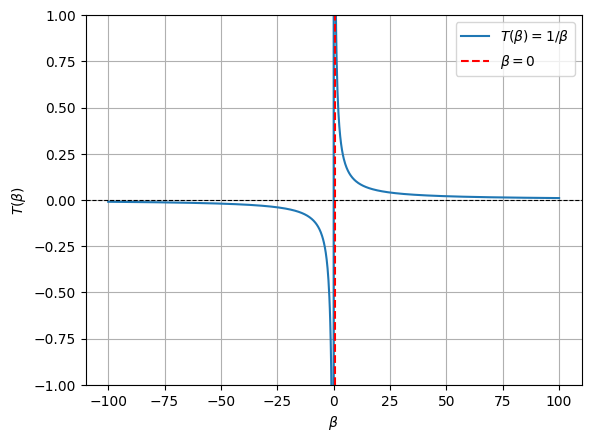

<Figure size 640x480 with 0 Axes>

In [57]:
# Plot
beta = np.linspace(-100, 100, 1000)
T_b = 1/beta

plt.plot(beta, T_b, label=r"$T(\beta) = 1/\beta$")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.axvline(0.5, color='red', linestyle='--', label=r'$\beta = 0$')
plt.xlabel(r'$\beta$', fontproperties=font_prop)
plt.ylabel(r'$T(\beta)$', fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.grid(True)
plt.ylim(-1, 1)
plt.show()

plt.savefig("temperature_vs_beta.pgf")


In [58]:
def probs_p(beta: float, N: int) -> np.ndarray:
    """
    Return p_i for given beta and N using stable formulas.
    Handles beta ~ 0 (a ~ 1) by taking the uniform limit.
    """
    if np.isclose(beta, 0.0, atol=1e-12):
        p = np.full(N, 1.0 / N, dtype=float)
    else:
        # a = exp(-beta); use expm1 to avoid catastrophic cancellation
        # 1 - a     = -expm1(-beta)
        # 1 - a^N   = -expm1(-beta*N)
        i = np.arange(N, dtype=float)
        ai = np.exp(-beta * i)
        numer_const = -np.expm1(-beta)         # = 1 - a
        denom = -np.expm1(-beta * N)           # = 1 - a^N
        p = (numer_const * ai) / denom
    # Defensive normalization
    p /= p.sum()
    return p


In [59]:
def entropy_S(beta: np.ndarray, N: int) -> np.ndarray:
    """
    Compute S(beta) = -sum p_i log p_i for an array of betas.
    """
    beta = np.atleast_1d(beta).astype(float)
    S = np.empty_like(beta, dtype=float)
    for k, b in enumerate(beta):
        p = probs_p(b, N)
        # clip to avoid log(0)
        p = np.clip(p, 1e-300, 1.0)
        S[k] = -np.sum(p * np.log(p))
    return S if S.size > 1 else S.item()


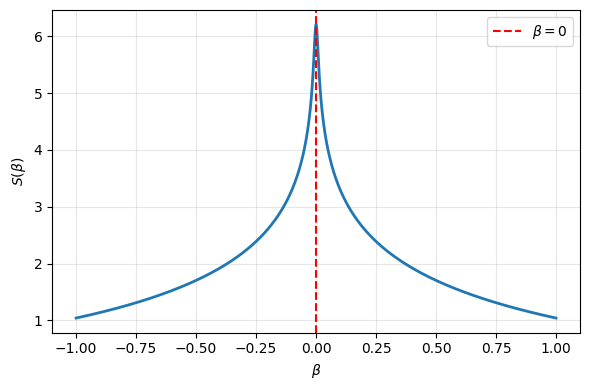

In [60]:
# Parameters
betas = np.linspace(-1, 1, 1000)
N = 500
# Compute
S_vals = entropy_S(betas, N)

plt.figure(figsize=(6, 4))
plt.plot(betas, S_vals, linewidth=2)
plt.xlabel(r"$\beta$", fontproperties=font_prop)
plt.ylabel(r"$S(\beta)$", fontproperties=font_prop)
plt.axvline(0, color='red', linestyle='--', label=r'$\beta = 0$')
plt.grid(True, alpha=0.3)
plt.legend(prop=font_prop)
plt.tight_layout()
plt.savefig("S_beta_plot.pgf")

plt.show()


C:\Users\pedro\AppData\Local\Temp\ipykernel_7704\2409974564.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop=font_prop)


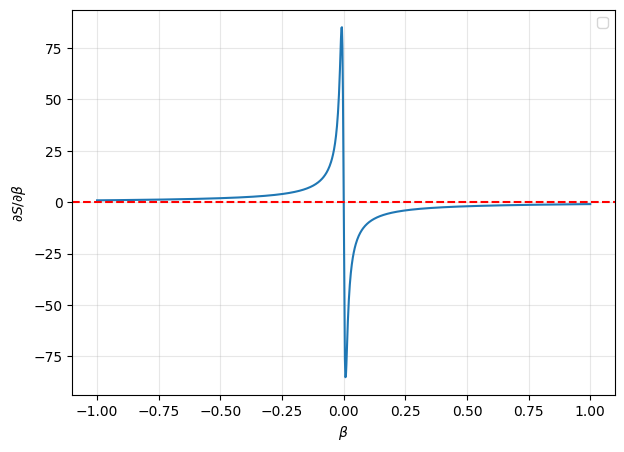

In [61]:
dS_dbeta = np.gradient(S_vals,  betas)
plt.figure(figsize=(7,5))
plt.plot(betas, dS_dbeta)
plt.xlabel(r"$\beta$", fontproperties=font_prop)
plt.ylabel(r"$\partial S / \partial \beta $", fontproperties=font_prop)
plt.axhline(0, color='red', linestyle='--')

plt.legend(prop=font_prop)
plt.grid(True, alpha=0.3)
plt.savefig("S_derivative_beta_plot.pgf")

plt.show()


In [62]:
def probs_p_from_T(T: float, N: int) -> np.ndarray:
    """
    Return p_i for given T and N.
    Uses beta = 1/T, handles T→∞ (beta→0) as uniform distribution.
    """
    if np.isclose(T, np.inf) or np.isclose(1.0/T, 0.0, atol=1e-12):
        return np.full(N, 1.0/N)
    
    beta = 1.0 / T
    if np.isclose(beta, 0.0, atol=1e-12):
        p = np.full(N, 1.0 / N)
    else:
        i = np.arange(N, dtype=float)
        ai = np.exp(-beta * i)
        numer_const = -np.expm1(-beta)       # 1 - a
        denom = -np.expm1(-beta * N)         # 1 - a^N
        p = (numer_const * ai) / denom
    p /= p.sum()
    return p

def entropy_S_T(T: np.ndarray, N: int) -> np.ndarray:
    """
    Compute S(T) for array of T values.
    """
    T = np.atleast_1d(T).astype(float)
    S = np.empty_like(T, dtype=float)
    for k, temp in enumerate(T):
        p = probs_p_from_T(temp, N)
        p = np.clip(p, 1e-300, 1.0)
        S[k] = -np.sum(p * np.log(p))
    return S if S.size > 1 else S.item()


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
C:\Users\pedro\AppData\Local\Temp\ipykernel_7704\1360840552.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\langle E \\rangle (\omega)$', fontproperties=font_prop, fontsize = 13)


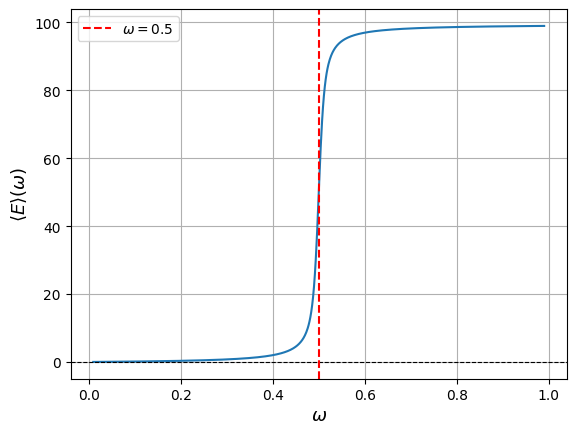

In [77]:
#plot of mean energy
N = 100
epsilon = 1

omega_values = np.linspace(0.01, 0.99, 1000)
energy_values = mean_energy(N, omega_values, epsilon)

plt.plot(omega_values, energy_values)
plt.xlabel(r'$\omega$', fontproperties=font_prop, fontsize = 13)
plt.ylabel('$\langle E \\rangle (\omega)$', fontproperties=font_prop, fontsize = 13)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0.5, color='red', linestyle='--', label=r'$\omega = 0.5$')
plt.legend(prop=font_prop, fontsize = 13)
plt.grid(True)
plt.savefig("mean_energy_vs_omega.pgf")
plt.show()



In [67]:
S_entropy(100,2/3,500)

np.float64(1.3879373885890778)

C:\Users\pedro\AppData\Local\Temp\ipykernel_7704\3117869861.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop=font_prop, fontsize = 13)


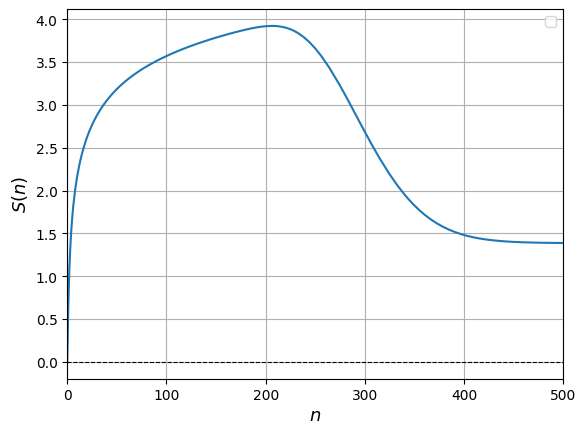

In [79]:
#Entropy of OQW
tmax = 500
N = 100
omega = 2/3


t_values = [0]*tmax
for i in range(tmax):
    t_values[i] = i

S_values = []
for t in range(len(t_values)):
    S_values.append(S_entropy(N,omega,t))


plt.plot(t_values, S_values)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.xlabel(r'$n$', fontproperties=font_prop, fontsize = 13)
plt.ylabel('$S(n)$', fontproperties=font_prop, fontsize = 13)
plt.legend(prop=font_prop, fontsize = 13)
plt.grid(True)
plt.xlim(0,500)
plt.savefig("oqw_entropy_1.pgf")

plt.show()


C:\Users\pedro\AppData\Local\Temp\ipykernel_7704\2564598624.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop=font_prop, fontsize = 13)


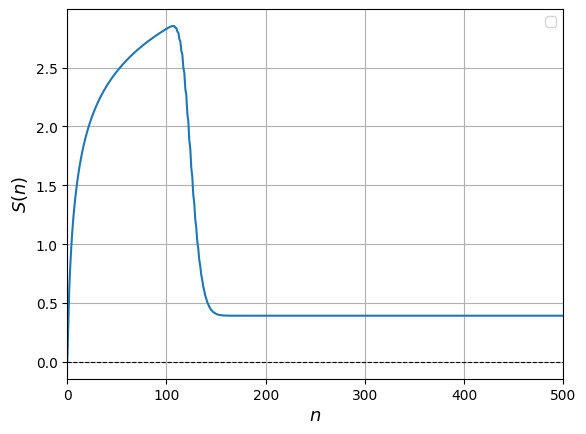

In [78]:
#Entropy of OQW
tmax = 500
N = 100
omega = 9/10


t_values = [0]*tmax
for i in range(tmax):
    t_values[i] = i

S_values = []
for t in range(len(t_values)):
    S_values.append(S_entropy(N,omega,t))


plt.plot(t_values, S_values)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.xlabel(r'$n$', fontproperties=font_prop, fontsize = 13)
plt.ylabel('$S(n)$', fontproperties=font_prop, fontsize = 13)
plt.legend(prop=font_prop, fontsize = 13)
plt.grid(True)
plt.xlim(0,500)
plt.savefig("oqw_entropy_2.pgf")

plt.show()


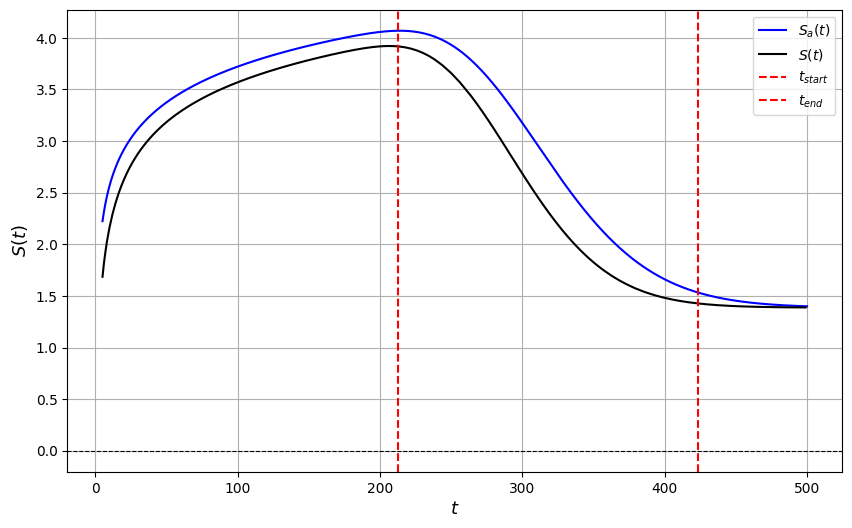

In [80]:
#Analytic Entropy of OQW
N = 100
omega = 2/3
tmax = 500


t_values_1 = np.linspace(5, tmax, 10000)
S_values_1 = S_corrected(N,omega,t_values_1)

t_values_2 = [0]*tmax

for i in range(tmax):
    t_values_2[i] = i

S_values_2 = []
for t in range(len(t_values_2)):
    S_values_2.append(S_entropy(N,omega,t))


t_values_3 = [0]*(tmax-5)
for i in range(tmax-5):
    t_values_3[i] = i

error = []
for t in range(5,len(t_values_2)):
    error.append(abs(S_values_2[t] - S_corrected(N,omega,t)))

plt.figure(figsize=(10, 6))


plt.plot(t_values_1, S_values_1, color = 'blue', label = '$S_{a}(t)$')
plt.plot(t_values_2[5:], S_values_2[5:], color = 'black', label = '$S(t)$')

tstart = t_start(N,omega)
tend = t_end(N,omega)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    

plt.axvline(tstart, color='red', linestyle='--', label=r'$t_{start}$')
plt.axvline(tend, color='red', linestyle='--', label=r'$t_{end}$')

plt.ylabel('$S(t)$', fontproperties=font_prop, fontsize = 13)
plt.xlabel(r'$t$', fontproperties=font_prop, fontsize = 13)
plt.legend(prop=font_prop, fontsize = 13)
plt.grid(True)
plt.savefig("comparison_oqw_entropy.pgf")
plt.show()

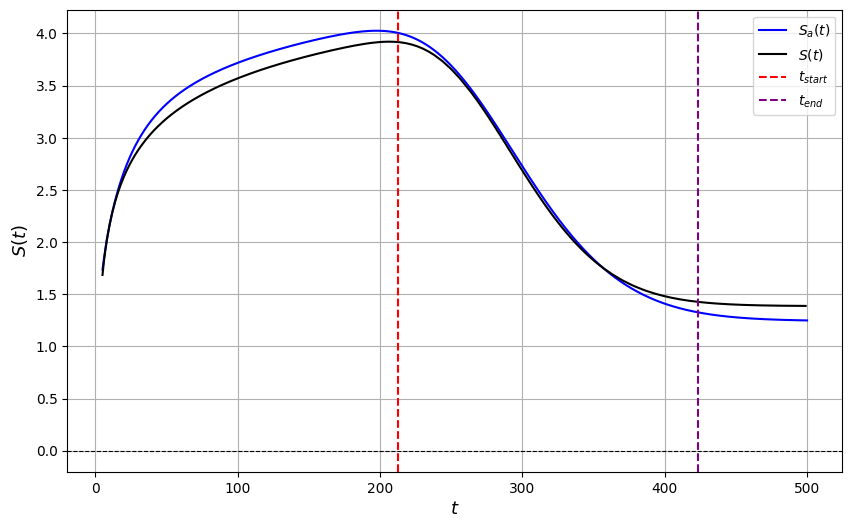

In [82]:
#Analytic Entropy of OQW - Part 2 
N = 100
omega = 2/3
tmax = 500


t_values_1 = np.linspace(5, tmax, 10000)
S_values_1 = S_a_2(N,omega,t_values_1)

t_values_2 = [0]*tmax

for i in range(tmax):
    t_values_2[i] = i

S_values_2 = []
for t in range(len(t_values_2)):
    S_values_2.append(S_entropy(N,omega,t))



plt.figure(figsize=(10, 6))


plt.plot(t_values_1, S_values_1, color = 'blue', label = '$S_{a}(t)$')
plt.plot(t_values_2[5:], S_values_2[5:], color = 'black', label = '$S(t)$')

tstart = t_start(N,omega)
tend = t_end(N,omega)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    

plt.axvline(tstart, color='red', linestyle='--', label=r'$t_{start}$')
plt.axvline(tend, color='purple', linestyle='--', label=r'$t_{end}$')

plt.xlabel(r'$t$', fontsize=13, fontproperties=font_prop)
plt.ylabel('$S(t)$', fontsize=13, fontproperties=font_prop)
plt.legend(fontsize=13, prop=font_prop)
plt.grid(True)
plt.savefig("comparison_oqw_entropy_2.pgf")
plt.show()

In [72]:
#average relative error between zero and t_end -> NEW ENTROPY FORMULA
t_values = []
S_exact_list = []
N = 100
omega = 2/3
for t in range(0, math.ceil(t_end(N,omega)+1)):
    S_exact = S_entropy(N, omega, t)
    S_exact_list.append(S_exact)
    t_values.append(t)
average_relative_error = sum([abs(S_exact_list[t] - S_a_2(N,omega,t))/S_exact_list[t] for t in range(5,len(t_values))]) / len(t_values)
average_absolute_error = sum([abs(S_exact_list[t] - S_a_2(N,omega,t)) for t in range(5,len(t_values))]) / len(t_values)
maximum_relative_error = max([abs(S_exact_list[t] - S_a_2(N,omega,t))/S_exact_list[t] for t in range(5,len(t_values))])
maximum_absolute_error = max([abs(S_exact_list[t] - S_a_2(N,omega,t)) for t in range(5,len(t_values))])
print("Average relative error between 0 and t_end:", average_relative_error)
print("Maximum relative error between 0 and t_end:", maximum_relative_error)
print("Maximum absolute error between 0 and t_end:", maximum_absolute_error)
print("Average scaled error between 0 and t_end:", average_absolute_error/np.log(N))
print("Maximum scaled error between 0 and t_end:", maximum_absolute_error/np.log(N))

Average relative error between 0 and t_end: 0.02743383082115517
Maximum relative error between 0 and t_end: 0.07094544181868824
Maximum absolute error between 0 and t_end: 0.15134040136356353
Average scaled error between 0 and t_end: 0.017872281525142152
Maximum scaled error between 0 and t_end: 0.0328631506006095


In [73]:
#average relative error between t_start and t_end -> NEW ENTROPY FORMULA
t_values = []
S_exact_list = []
N = 100
omega = 2/3
t_start_value = math.ceil(t_start(N,omega))
for t in range(t_start_value, math.ceil(t_end(N,omega)+1)):
    S_exact = S_entropy(N, omega, t)
    S_exact_list.append(S_exact)
    t_values.append(t)
average_relative_error = sum([abs(S_exact_list[t - t_start_value] - S_a_2(N,omega,t))/S_exact_list[t - t_start_value] for t in range(t_start_value, len(t_values)+t_start_value)]) / len(t_values)
average_absolute_error = sum([abs(S_exact_list[t - t_start_value] - S_a_2(N,omega,t)) for t in range(t_start_value, len(t_values)+t_start_value)]) / len(t_values)
maximum_relative_error = max([abs(S_exact_list[t - t_start_value] - S_a_2(N,omega,t))/S_exact_list[t - t_start_value] for t in range(t_start_value, len(t_values)+t_start_value)])
maximum_absolute_error = max([abs(S_exact_list[t - t_start_value] - S_a_2(N,omega,t)) for t in range(t_start_value, len(t_values)+t_start_value)])
print("Average relative error between t_start and t_end:", average_relative_error)
print("Maximum relative error between t_start and t_end:", maximum_relative_error)
print("Maximum absolute error between t_start and t_end:", maximum_absolute_error)
print("Average scaled error between t_start and t_end:", average_absolute_error/np.log(N))
print("Maximum scaled error between t_start and t_end:", maximum_absolute_error/np.log(N))

Average relative error between t_start and t_end: 0.020572329863134522
Maximum relative error between t_start and t_end: 0.07094544181868824
Maximum absolute error between t_start and t_end: 0.10116536169317003
Average scaled error between t_start and t_end: 0.009500745872423272
Maximum scaled error between t_start and t_end: 0.021967779171545177


In [74]:
#average relative error between zero and t_end
t_values = []
S_exact_list = []
N = 100
omega = 2/3
for t in range(0, math.ceil(t_end(N,omega)+1)):
    S_exact = S_entropy(N, omega, t)
    S_exact_list.append(S_exact)
    t_values.append(t)
average_relative_error = sum([abs(S_exact_list[t] - S_corrected(N,omega,t))/S_exact_list[t] for t in range(5,len(t_values))]) / len(t_values)
average_absolute_error = sum([abs(S_exact_list[t] - S_corrected(N,omega,t)) for t in range(5,len(t_values))]) / len(t_values)
maximum_relative_error = max([abs(S_exact_list[t] - S_corrected(N,omega,t))/S_exact_list[t] for t in range(5,len(t_values))])
maximum_absolute_error = max([abs(S_exact_list[t] - S_corrected(N,omega,t)) for t in range(5,len(t_values))])
print("Average relative error between 0 and t_end:", average_relative_error)
print("Maximum relative error between 0 and t_end:", maximum_relative_error)
print("Maximum absolute error between 0 and t_end:", maximum_absolute_error)
print("Average scaled error between 0 and t_end:", average_absolute_error/np.log(N))
print("Maximum scaled error between 0 and t_end:", maximum_absolute_error/np.log(N))

Average relative error between 0 and t_end: 0.09878447744268776
Maximum relative error between 0 and t_end: 0.3196456568789911
Maximum absolute error between 0 and t_end: 0.5386161468231712
Average scaled error between 0 and t_end: 0.05410608131788654
Maximum scaled error between 0 and t_end: 0.11695901021464745


In [75]:
#average relative error between t_start and t_end
N = 100
omega = 2/3

error = []
scaled_error =  []
for t in range(math.ceil(t_start(N,omega)), math.ceil(t_end(N,omega)+1)):
    S_exact = S_entropy(N, omega, t)
    S_analytic = S_corrected(N, omega, t)
    error.append(abs(S_exact - S_analytic)/S_exact)
    scaled_error.append(abs(S_exact - S_analytic)/np.log(N))
average_relative_error = sum(error) / len(error)
print("Average relative error between t_start and t_end:", average_relative_error)
scaled_relative_error = sum(scaled_error) / len(scaled_error)
print("Average scaled error between t_start and t_end:", scaled_relative_error)

Average relative error between t_start and t_end: 0.14247545267445577
Average scaled error between t_start and t_end: 0.07048062297237599


In [76]:
#maximum relative error between zero and t_end
N = 100
omega = 2/3

t_values = []
for t in range(0, math.ceil(t_end(N,omega)+1)):
    t_values.append(t)
relative_errors = [abs(S_entropy(N, omega, t) - S_corrected(N,omega,t))/S_entropy(N, omega, t) for t in range(5,len(t_values))]
max_relative_error = max(relative_errors)
print("Maximum relative error between 0 and t_end:", max_relative_error)

KeyboardInterrupt: 

In [ ]:
#maximum absolute error between zero and t_end
N = 100
omega = 2/3

t_values = []
for t in range(0, math.ceil(t_end(N,omega)+1)):
    t_values.append(t)
absolute_errors = [abs(S_entropy(N, omega, t) - S_corrected(N,omega,t)) for t in range(5,len(t_values))]
max_absolute_error = max(absolute_errors)
print("Maximum absolute error between 0 and t_end:", max_absolute_error)
print("Maximum scaled error between 0 and t_end:", max_absolute_error/np.log(N))

Maximum absolute error between 0 and t_end: 0.5386161468231712
Maximum scaled error between 0 and t_end: 0.11695901021464745


Sum_x P(x,t) = 0.9981434195812323


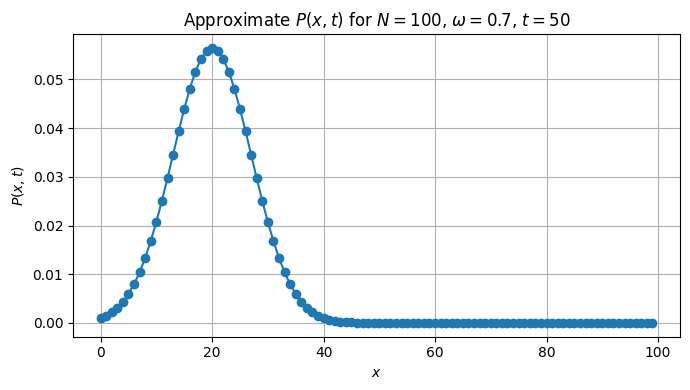

In [ ]:
# --- Parameters (change these as you like) ---
N = 100        # number of sites
omega = 0.7    # coin parameter
t = 50         # fixed time

# x from 0 to N-1 (or 0 to N, depending on how you defined the walk)
x_vals = np.arange(0, N)

# Compute P(x,t) for each x
P_vals = np.array([Prob_approximation(N, omega, x, t) for x in x_vals])

# Optional: check normalization
print("Sum_x P(x,t) =", P_vals.sum())

# --- Plot ---
plt.figure(figsize=(7,4))
plt.plot(x_vals, P_vals, marker='o', linestyle='-')
plt.xlabel(r'$x$')
plt.ylabel(r'$P(x,t)$')
plt.title(fr'Approximate $P(x,t)$ for $N={N}$, $\omega={omega}$, $t={t}$')
plt.grid(True)
plt.tight_layout()
plt.show()

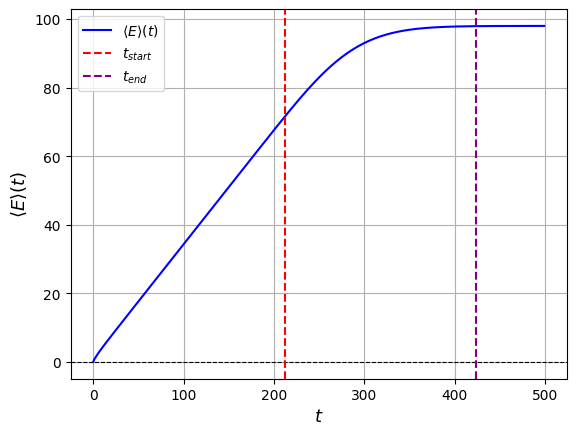

In [87]:
#Mean Energy evolution 
N = 100
omega = 2/3
tmax = 500
epsilon = 1
t_values = [0]*tmax
for i in range(tmax):
    t_values[i] = i

mean_enegy_values = []
for t in range(tmax):
    mean_enegy_values.append(mean_energy_evolution(N,omega,epsilon,t))



plt.plot(t_values, mean_enegy_values, color = 'blue', label = r'$\langle E \rangle (t)$')

tstart = t_start(N,omega)
tend = t_end(N,omega)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    

plt.axvline(tstart, color='red', linestyle='--', label=r'$t_{start}$')
plt.axvline(tend, color='purple', linestyle='--', label=r'$t_{end}$')

plt.xlabel(r'$t$', fontsize=13, fontproperties=font_prop)
plt.ylabel(r'$\langle E \rangle (t)$', fontsize=13, fontproperties=font_prop)
plt.legend(prop=font_prop, fontsize = 13)
plt.grid(True)
plt.savefig("mean_energy_evolution.pgf")
plt.show()

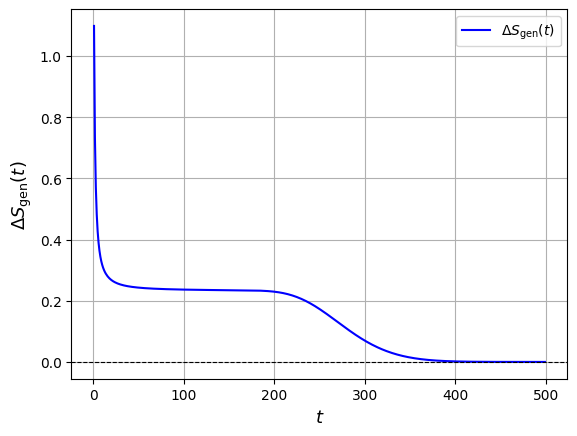

In [ ]:
# Entropy production plot
N = 100
omega = 2/3
tmax = 500
epsilon = 1

# Times: t = 0, 1, ..., tmax-1
t_values = np.arange(tmax)

# Mean energy ⟨E⟩(t)
mean_energy_values = np.array([
    mean_energy_evolution(N, omega, epsilon, t) for t in t_values
])

# Entropy S(t)
entropy_values = np.array([
    S_entropy(N, omega, t) for t in t_values
])

# ΔE(t) = E(t) - E(t-1), for t = 1,...,tmax-1
delta_energy_values = mean_energy_values[1:] - mean_energy_values[:-1]

# ΔS(t) = S(t) - S(t-1), for t = 1,...,tmax-1
delta_entropy_values = entropy_values[1:] - entropy_values[:-1]

# Temperature (constant in your model)
T = -epsilon / np.log(omega / (1 - omega))

# ΔE/T
delta_energy_divided_by_T = delta_energy_values / T

# Entropy generated ΔS_gen(t) = ΔS(t) - ΔE(t)/T
generated_entropy = delta_entropy_values - delta_energy_divided_by_T

# Plot vs t = 1,...,tmax-1
plt.plot(t_values[1:], generated_entropy, color='blue', label=r'$\Delta S_{\text{gen}}(t)$')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True)
plt.ylabel(r'$\Delta S_{\text{gen}}(t)$', fontsize=13)
plt.xlabel(r'$t$', fontsize=13)
plt.legend()
plt.show()


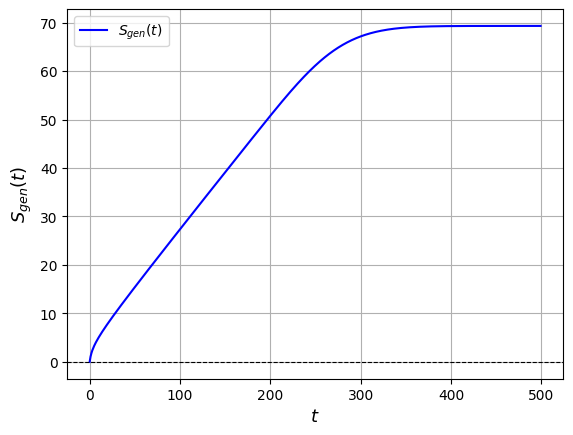

In [88]:
# Entropy production plot
N = 100
omega = 2/3
tmax = 500
epsilon = 1

# Times: t = 0, 1, ..., tmax-1
t_values = np.arange(tmax)

# Mean energy ⟨E⟩(t)
mean_energy_values = np.array([
    mean_energy_evolution(N, omega, epsilon, t) for t in t_values
])

# Entropy S(t)
entropy_values = np.array([
    S_entropy(N, omega, t) for t in t_values
])


# Temperature (constant in your model)
T = -epsilon / np.log(omega / (1 - omega))

# ΔE/T
energy_divided_by_T = mean_energy_values / T

# Entropy generated S_gen(t) = S(t) - E(t)/T
generated_entropy_values = entropy_values - energy_divided_by_T

# Plot vs t = 1,...,tmax-1
plt.plot(t_values[:], generated_entropy_values, color='blue', label=r'$S_{gen}(t)$')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True)
plt.ylabel(r'$S_{gen}(t)$', fontsize=13, fontproperties=font_prop)
plt.xlabel(r'$t$', fontsize=13, fontproperties=font_prop)
plt.legend(prop=font_prop, fontsize = 13)
plt.savefig("entropy_production.pgf")
plt.show()


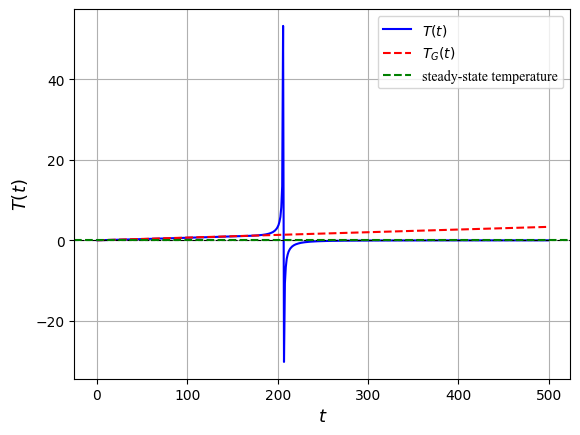

In [92]:
#Derivative of entropy with respect to mean energy
N = 100
omega = 2/3
tmax = 500
t_values = np.arange(tmax)
epsilon = 0.01
S_values = np.array([
    S_entropy(N, omega, t) for t in t_values
])
mean_energy_values = np.array([
    mean_energy_evolution(N, omega, epsilon, t) for t in t_values
])
dS_dt = np.gradient(S_values,  t_values)
dE_dt = np.gradient(mean_energy_values,  t_values)
T_vals = dE_dt / dS_dt

T_gaussian = 2*(2*omega-1)*epsilon * t_values

plt.plot(t_values, T_vals, color='blue', label=r'$T(t)$')
plt.plot(t_values, T_gaussian, color='red', linestyle='--', label=r'$T_G(t)$')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel(r'$t$', fontsize=13, fontproperties=font_prop)
plt.ylabel(r'$T(t)$', fontsize=13, fontproperties=font_prop)
plt.axhline(- epsilon/ (np.log(omega / (1 - omega))), color='green', linestyle='--', label = r'steady-state temperature')
plt.legend(prop=font_prop, fontsize = 13)
plt.grid(True)
plt.savefig("evolution_temperature.pgf")
plt.show()